In [1]:
import sys, os, logging, gc
import numpy as np
from scipy import optimize

from astropy.cosmology import Planck18
import py21cmfast as p21c
from py21cmfast import cache_tools

is_josh = False
if is_josh:

    os.environ['DM21CM_DIR'] = '/global/scratch/projects/pc_heptheory/fosterjw/21CM_Project/DM21cm/'
    os.environ['DM21CM_DATA_DIR'] =  '/global/scratch/projects/pc_heptheory/fosterjw/21CM_Project/Data01/'

    os.environ['DH_DIR'] = '/global/scratch/projects/pc_heptheory/fosterjw/21CM_Project/DarkHistory/'
    os.environ['DH_DATA_DIR'] = '/global/scratch/projects/pc_heptheory/fosterjw/21CM_Project/DarkHistory/DHData/'

    os.environ['P21C_CACHE_DIR'] = './TestCache/'
    
import numpy as np
from scipy import interpolate
from astropy.cosmology import Planck18
import astropy.units as u

from jax import config
config.update("jax_enable_x64", True)
import jax.numpy as jnp

import py21cmfast as p21c
from py21cmfast import cache_tools

sys.path.append(os.environ['DH_DIR'])
from darkhistory.spec.spectrum import Spectrum

sys.path.append(os.environ['DM21CM_DIR'])
import dm21cm.physics as phys
from dm21cm.dh_wrappers import DarkHistoryWrapper, TransferFunctionWrapper
from dm21cm.utils import load_h5_dict
from dm21cm.data_cacher import Cacher
from dm21cm.profiler import Profiler

logging.getLogger().setLevel(logging.INFO)
logging.getLogger('21cmFAST').setLevel(logging.CRITICAL+1)
logging.getLogger('py21cmfast._utils').setLevel(logging.CRITICAL+1)
logging.getLogger('py21cmfast.wrapper').setLevel(logging.CRITICAL+1)

#######################################
###   Import and Construct DM21cm   ###
#######################################

cache_dir = os.environ['P21C_CACHE_DIR']

os.environ['P21C_CACHE_DIR'] = cache_dir
p21c.config['direc'] = os.environ['P21C_CACHE_DIR']
WDIR = os.environ['DM21CM_DIR']
sys.path.append(WDIR)
from dm21cm.dm_params import DMParams
#from dm21cm.evolve import evolve

use_tqdm = True

/n/home07/yitians/.conda/envs/dm21cm/lib/python3.11/site-packages/py21cmfast/_cfg.py:58: UserWarning: Your configuration file is out of date. Updating...
  warnings.warn(
/n/home07/yitians/.conda/envs/dm21cm/lib/python3.11/site-packages/py21cmfast/_cfg.py:42: UserWarning: Your configuration file is out of date. Updating...
  warnings.warn("Your configuration file is out of date. Updating...")


In [2]:
from dm21cm.evolve import get_z_edges, split_xray, gen_injection_boxes, get_r_shells

In [3]:
run_name = 'test_in_step'
z_start = 45.
z_end = 5.
dm_params = DMParams(
    mode='decay',
    primary='phot_delta',
    m_DM=3e3, # [eV]
    lifetime=1e26, # [s]
)
enable_elec = False

p21c_initial_conditions = p21c.initial_conditions(
    user_params = p21c.UserParams(
        HII_DIM = 32,
        BOX_LEN = 32*2, # [conformal Mpc]
        N_THREADS = 32,
    ),
    cosmo_params = p21c.CosmoParams(
        OMm = Planck18.Om0,
        OMb = Planck18.Ob0,
        POWER_INDEX = Planck18.meta['n'],
        #SIGMA_8 = Planck18.meta['sigma8'],
        SIGMA_8 = 1e-6,
        hlittle = Planck18.h,
    ),
    random_seed = 54321,
    write = True,
)
# p21c_astro_params = p21c.AstroParams._defaults_
# astro_params = p21c_astro_params
astro_params = None
p21c_astro_params = None
clear_cache = True
use_DH_init = True
no_injection = False
tf_on_device = True
rerun_DH = False
use_xray_interp_shell = True

/n/home07/yitians/.conda/envs/dm21cm/lib/python3.11/site-packages/py21cmfast/inputs.py:487: UserWarning: The USE_INTERPOLATION_TABLES setting has changed in v3.1.2 to be default True. You can likely ignore this warning, but if you relied onhaving USE_INTERPOLATION_TABLES=False by *default*, please set it explicitly. To silence this warning, set it explicitly to True. Thiswarning will be removed in v4.
  warnings.warn(


In [4]:
def p21c_step(perturbed_field, spin_temp, ionized_box,
             input_heating=None, input_ionization=None, input_jalpha=None, astro_params=astro_params):

    spin_temp = p21c.spin_temperature(
        perturbed_field = perturbed_field,
        previous_spin_temp = spin_temp,
        input_heating_box = input_heating,
        input_ionization_box = input_ionization,
        input_jalpha_box = input_jalpha,
        astro_params = astro_params,
    )

    ionized_box = p21c.ionize_box(
        perturbed_field = perturbed_field,
        previous_ionize_box = ionized_box,
        spin_temp = spin_temp,
        astro_params = astro_params,
    )

    brightness_temp = p21c.brightness_temperature(
        ionized_box = ionized_box,
        perturbed_field = perturbed_field,
        spin_temp = spin_temp,
    )

    return spin_temp, ionized_box, brightness_temp

In [5]:
if is_josh:
    data_dir = os.environ['DM21CM_DATA_DIR']
else:
    data_dir = os.environ['DM21CM_DATA_DIR'] + '/tf/zf01/data'
cache_dir = os.environ['P21C_CACHE_DIR'] + '/' + run_name
p21c.config['direc'] = cache_dir
logging.info(f"Cache dir: {cache_dir}")
os.makedirs(cache_dir, exist_ok=True)
if clear_cache:
    cache_tools.clear_cache()
gc.collect()

#===== initialize =====
#--- physics parameters ---
abscs = load_h5_dict(f"{data_dir}/abscissas.h5")
dm_params.set_inj_specs(abscs)

EPSILON = 1e-6
p21c.global_params.Z_HEAT_MAX = z_start + EPSILON
p21c.global_params.ZPRIME_STEP_FACTOR = abscs['zplusone_step_factor']

box_dim = p21c_initial_conditions.user_params.HII_DIM
box_len = p21c_initial_conditions.user_params.BOX_LEN
cosmo = Planck18

#--- DarkHistory and transfer functions ---
tf_wrapper = TransferFunctionWrapper(
    box_dim = box_dim,
    abscs = abscs,
    prefix = data_dir,
    enable_elec = enable_elec,
    on_device = tf_on_device,
)

INFO:root:Cache dir: /n/holyscratch01/iaifi_lab/yitians/21cmFAST-cache/test_in_step
INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': NOT_FOUND: Could not find registered platform with name: "rocm". Available platform names are: Interpreter CUDA
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': module 'jaxlib.xla_extension' has no attribute 'get_tpu_client'
INFO:root:TransferFunctionWrapper: Loaded photon transfer functions.
INFO:root:TransferFunctionWrapper: Skipping electron transfer functions.


In [6]:
#--- xray ---
xray_cacher = Cacher(box_dim=box_dim, dx=box_len/box_dim)

#--- redshift stepping ---
z_edges = get_z_edges(z_start, z_end, p21c.global_params.ZPRIME_STEP_FACTOR)

#===== initial steps =====
dh_wrapper = DarkHistoryWrapper(dm_params, prefix=p21c.config[f'direc'])

# We have to synchronize at the second step because 21cmFAST acts weird in the first step:
# - global_params.TK_at_Z_HEAT_MAX is not set correctly (it is probably set and evolved for a step)
# - global_params.XION_at_Z_HEAT_MAX is not set correctly (it is probably set and evolved for a step)
# - first step ignores any values added to spin_temp.Tk_box and spin_temp.x_e_box
z_match = z_edges[1]
if use_DH_init:
    dh_wrapper.evolve(end_rs=(1+z_match)*0.9, rerun=rerun_DH)
    T_k_DH_init, x_e_DH_init, phot_bath_spec = dh_wrapper.get_init_cond(rs=1+z_match)
else:
    phot_bath_spec = Spectrum(abscs['photE'], np.zeros_like(abscs['photE']), spec_type='N', rs=1+z_match) # [ph / Bavg]

INFO:root:DarkHistoryWrapper: Found existing DarkHistory initial conditions.
INFO:root:DarkHistoryWrapper: Running DarkHistory to generate initial conditions...


****** Loading transfer functions... ******
Using data at /n/holyscratch01/iaifi_lab/yitians/darkhistory/DHdata_v1_1
    for propagating photons...   Done!
    for low-energy photons...  Done!
    for low-energy electrons...  Done!
    for high-energy deposition...  Done!
    for total upscattered CMB energy rate...  Done!
****** Loading complete! ******
****** Loading transfer functions... ******
    for inverse Compton (Thomson)...  Done!
    for inverse Compton (relativistic)...  Done!
    for inverse Compton (energy loss)...  Done!
****** Loading complete! ******
Loading time: 6.121 s


  0%|          | 2/430 [00:00<00:34, 12.52it/s]

Initialization time: 0.045 s


100%|██████████| 430/430 [00:49<00:00,  8.75it/s]
INFO:root:DarkHistoryWrapper: Saved DarkHistory initial conditions.


Main loop time: 49.123 s


In [7]:
perturbed_field = p21c.perturb_field(redshift=z_edges[1], init_boxes=p21c_initial_conditions, write = True)
spin_temp, ionized_box, brightness_temp = p21c_step(perturbed_field=perturbed_field, spin_temp=None, ionized_box=None, astro_params=p21c_astro_params)
if use_DH_init:
    spin_temp.Tk_box += T_k_DH_init - np.mean(spin_temp.Tk_box)
    spin_temp.x_e_box += x_e_DH_init - np.mean(spin_temp.x_e_box)
    ionized_box.xH_box = 1 - spin_temp.x_e_box

#===== main loop =====
z_edges = z_edges[1:] # Maybe fix this later
z_range = range(len(z_edges)-1)
records = []
profiler = Profiler()

#--- trackers ---
i_xray_loop_start = 0 # where we start looking for annuli

## LOOP START

In [8]:
i_z = 0

In [14]:
i_z += 1
print(i_z)

1


In [9]:
print(f'i_z={i_z}/{len(z_edges)-2} z={z_edges[i_z]:.2f}')

#===== physical quantities =====
z_current = z_edges[i_z]
z_next = z_edges[i_z+1]
dt = phys.dt_step(z_current, np.exp(abscs['dlnz']))

#--- for interpolation ---
delta_plus_one_box = 1 + np.asarray(perturbed_field.density)
x_e_box = np.asarray(1 - ionized_box.xH_box)
T_k_box = np.asarray(spin_temp.Tk_box)
tf_wrapper.init_step(rs=1+z_current, delta_plus_one_box=delta_plus_one_box, x_e_box=x_e_box, T_k_box=T_k_box)

#--- for dark matter ---
nBavg = phys.n_B * (1+z_current)**3 # [Bavg / (physical cm)^3]
rho_DM_box = delta_plus_one_box * phys.rho_DM * (1+z_current)**3 # [eV/(physical cm)^3]
inj_per_Bavg_box = phys.inj_rate(rho_DM_box, dm_params) * dt * dm_params.struct_boost(1+z_current) / nBavg # [inj/Bavg]

i_z=0/203 z=44.68


## first step

In [10]:
zero_spectrum = Spectrum(abscs['photE'], np.zeros_like(abscs['photE']), spec_type='N', rs=1+z_current)
xray_cacher.cache(z_current-1, z_current, zero_spectrum, np.zeros((box_dim, box_dim, box_dim)))

## otherwise

In [16]:
# conformal distance [cMpc] of z from current shell
r_from_z = np.vectorize(lambda z: phys.conformal_dx_between_z(z_current, z))

# inverse of r_z
z_from_r = interpolate.interp1d(r_from_z(np.geomspace(z_current, 200., 1000)),
                                np.geomspace(z_current, 200., 1000),
                                bounds_error=False, fill_value='extrapolate')

# Get the list of r-shells we smooth over
r_shells = get_r_shells(box_dim, box_len, n_target=40) # R_a in paper
cached_r = r_from_z(xray_cacher.z_s)
# print(cached_r)
# print(xray_cacher.z_s)

r_max = np.min([box_len/2, np.amax(cached_r)])
r_shells = np.unique(np.minimum(r_shells, np.amin(cached_r[cached_r >= r_max])))

In [17]:
xray_cacher.states[0].ephemeral

True

In [18]:
r_shells

array([ 0.        ,  1.24070098,  1.44145038,  1.67468168,  1.94565055,
        2.26046306,  2.62621324,  3.05114297,  3.54482769,  4.11839219,
        4.78476127,  5.558951  ,  6.45840711,  7.50339811,  8.71747201,
       10.12798696, 11.70545473])

In [19]:
# # Don't smooth farther back then we have data
# if np.amax(cached_r) < np.amax(r_shells):
#     r_shells = np.unique(np.minimum(np.amax(cached_r), r_shells))

# # Go past box_len/2 to the next redshift cache in the interest of ending on a state
# else:
#     r_shells = np.union1d(r_shells, np.amin(cached_r[np.where(cached_r > np.amax(r_shells))]))

# (Min, Max) pairs of the radii on which we smooth
r_pairs = np.stack((r_shells[:-1], r_shells[1:]), axis = -1)

# The midpoint smoothing radius and associated redshift
r_mid = (r_shells[1:] + r_shells[:-1]) / 2 # The midpoint of the smoothing
z_mid = z_from_r(r_mid) # Z for the midpoint of the smoothing edge

# The delta-z of the smoothing interval. Used to go from dEdz -> \Delta E
dz = np.diff(z_from_r(r_pairs), axis = 1)

In [20]:
dz

array([[0.0476322 ],
       [0.00770704],
       [0.00895407],
       [0.0104203 ],
       [0.01211296],
       [0.01407287],
       [0.01634991],
       [0.01900079],
       [0.02211797],
       [0.02569673],
       [0.02988358],
       [0.03476225],
       [0.04043376],
       [0.04702796],
       [0.05475647],
       [0.06134776]])

In [21]:
np.sum(dz)

0.45227660898426336

In [132]:
z_bath_arr = []
dEdz_bath_arr = []

In [133]:
for i, state in enumerate(xray_cacher.states[::-1]):
    depion_before = np.mean(tf_wrapper.dep_box[..., 0])
    tf_wrapper.inject_phot(state.spectrum, inject_type='xray', weight_box=jnp.ones((box_dim, box_dim, box_dim)))
    depion = np.mean(tf_wrapper.dep_box[..., 0]) - depion_before
    z_bath_arr.append(state.z_end)
    dEdz_bath_arr.append(depion / np.abs(state.z_end - state.z_start))
    print(i, state.z_end, depion)

0 43.335068182089486 2.3606363998910995e-11
1 43.77841886391038 1.6185269007794523e-13
2 44.22620305254949 3.5558739957688885e-14
3 44.67846508307498 3.5558739957637187e-14


In [137]:
xray_cacher.states[0].z_start

45.13072711360048

In [138]:
z_bath_arr.append(xray_cacher.states[0].z_start)
print(z_bath_arr)

[43.335068182089486, 43.77841886391038, 44.22620305254949, 44.67846508307498, 45.13072711360048]


In [77]:
np.mean(tf_wrapper.dep_box[..., 0])

Array(2.38393342e-11, dtype=float64)

In [22]:
tf_wrapper.dep_box *= 0.

z_arr = []
dEdz_arr = []

# Do the interpolated smoothing loop
for i in range(len(z_mid)):

    # Deciding on the interpolation nodes
    left_z = np.amin(xray_cacher.z_s[xray_cacher.z_s >= z_mid[i]])
    right_z = np.amax(xray_cacher.z_s[xray_cacher.z_s < z_mid[i]])
    assert left_z > z_mid[i] > right_z
    print(left_z, z_mid[i], right_z)

    # Data at interpolation nodes
    ftdEdz_right, rel_spec_right = xray_cacher.get_ftdEdz_spec(right_z)
    ftdEdz_left,  rel_spec_left  = xray_cacher.get_ftdEdz_spec(left_z)

    # Linear interpolation weights
    left_weight = (right_z - z_mid[i]) / (right_z - left_z)
    right_weight = 1 - left_weight

    # Weighted emissivity box
    ftdEdz = left_weight * ftdEdz_left + right_weight * ftdEdz_right
    rel_spec = left_weight * rel_spec_left + right_weight * rel_spec_right

    # Do the smoothing and injection
    dE = xray_cacher.smooth_box(ftdEdz, r_pairs[i, 0], r_pairs[i, 1])*dz[i]

    depion_before = np.mean(tf_wrapper.dep_box[...,0])
    tf_wrapper.inject_phot(rel_spec, inject_type='xray', weight_box=dE)
    depion_after = np.mean(tf_wrapper.dep_box[...,0])
    print(i, dz[i] / (left_z - right_z))
    print(i, f'{left_weight:.3f} {right_weight:.3f}')
    print(i, f'{np.mean(np.fft.irfftn(ftdEdz_left))} {np.mean(np.fft.irfftn(ftdEdz_right))}')
    print(i, f'{rel_spec_left.toteng()} {rel_spec_right.toteng()}')
    print(i, f'{depion_after - depion_before:.3e}')
    z_arr.append(z_mid[i])
    dEdz_arr.append((depion_after - depion_before)/dz[i])

    #del ftdEdz_right, ftdEdz_left, ftdEdz, rel_spec_right, rel_spec_left, rel_spec
    gc.collect()

# We engineered our smoothing radii to end on a cached state. Now we dump everything prior
# to that cached state because it will never get used
# print(i_z, r_pairs)
# print(r_shells)
# print('Dumping states before:', z_from_r(np.amax(r_pairs)))
# print('Radius of dumped states will be larger than:', np.amax(r_pairs))


########################
###   End New Code   ###
########################

44.67846508307498 44.25001915018379 44.22620305254949
0 [0.10531991]
0 0.053 0.947
0 2.2332186472219493 2.2332186472219493
0 6.283095168181527e-11 6.283095168181527e-11
0 2.548e-12
44.67846508307498 44.277688768857665 44.22620305254949
1 [0.0170411]
1 0.114 0.886
1 2.2332186472219493 2.2332186472219493
1 6.283095168181527e-11 6.283095168181527e-11
1 4.118e-13
44.67846508307498 44.28601932300963 44.22620305254949
2 [0.0197984]
2 0.132 0.868
2 2.2332186472219493 2.2332186472219493
2 6.283095168181527e-11 6.283095168181527e-11
2 4.788e-13
44.67846508307498 44.295703659037805 44.22620305254949
3 [0.02304041]
3 0.154 0.846
3 2.2332186472219493 2.2332186472219493
3 6.283095168181527e-11 6.283095168181527e-11
3 5.575e-13
44.67846508307498 44.30697313733491 44.22620305254949
4 [0.02678305]
4 0.179 0.821
4 2.2332186472219493 2.2332186472219493
4 6.283095168181527e-11 6.283095168181527e-11
4 6.476e-13
44.67846508307498 44.32006605339205 44.22620305254949
5 [0.03111664]
5 0.208 0.792
5 2.23321864

In [85]:
import matplotlib.pyplot as plt

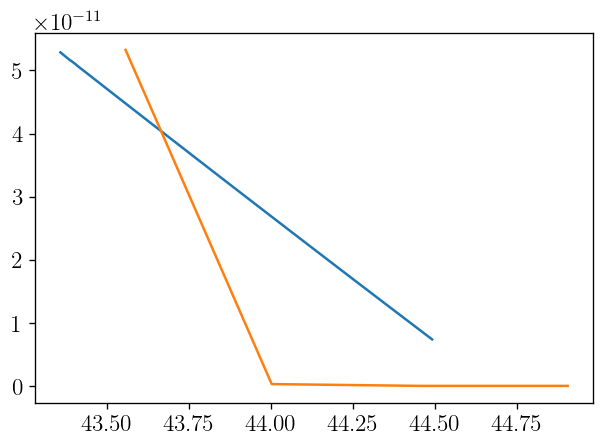

In [102]:
plt.plot(z_arr, dEdz_arr)
plt.plot(z_bath_arr, np.array(dEdz_bath_arr))

In [114]:
z_shells = z_from_r(r_shells)

In [117]:
len(z_shells), len(z_arr)

(24, 23)

In [108]:
np.array(z_arr), np.array(dEdz_arr).flatten()

(array([43.35818242, 43.38503661, 43.39312167, 43.40251728, 43.41345497,
        43.4261624 , 43.44092594, 43.45807826, 43.47802854, 43.50123268,
        43.52819132, 43.5595682 , 43.59603861, 43.63849377, 43.68787653,
        43.74535033, 43.81227   , 43.89021322, 43.9810172 , 44.08685697,
        44.21028746, 44.3543467 , 44.49124412]),
 array([5.28473823e-11, 5.17071752e-11, 5.14187817e-11, 5.10586824e-11,
        5.05744913e-11, 5.00672477e-11, 4.94691584e-11, 4.87711500e-11,
        4.79632763e-11, 4.70212636e-11, 4.59271669e-11, 4.46575978e-11,
        4.31809904e-11, 4.14642521e-11, 3.94700706e-11, 3.71537761e-11,
        3.44604354e-11, 3.13311399e-11, 2.76936533e-11, 2.34665317e-11,
        1.85532176e-11, 1.28414169e-11, 7.43612341e-12]))

In [122]:
np.diff(z_shells)

array([0.04622847, 0.00747992, 0.00869019, 0.01011004, 0.01175633,
       0.01365854, 0.01586854, 0.01843612, 0.02146591, 0.02494089,
       0.02899472, 0.03374073, 0.03923251, 0.04564539, 0.05313529,
       0.06184332, 0.07200764, 0.08386777, 0.0977619 , 0.11395377,
       0.13294959, 0.15521854, 0.11849313])

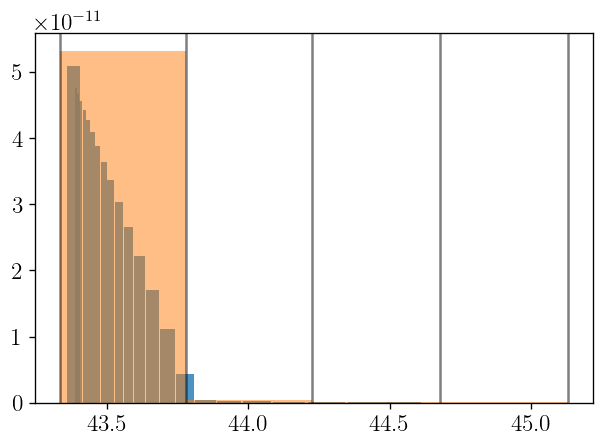

In [145]:
plt.bar(z_mid, np.array(dEdz_arr).flatten(), align='edge', width=np.diff(z_shells), alpha=0.8)
plt.bar(z_bath_arr[:-1], np.array(dEdz_bath_arr), alpha=0.5, align='edge', width=np.diff(z_bath_arr))
for z in z_bath_arr:
    plt.axvline(z, color='k', alpha=0.5)

In [72]:
for i, state in enumerate(xray_cacher.states):
    print(i, state.spectrum.toteng(), np.mean(np.fft.irfftn(state.ftbox)))

0 5.267338664600816e-13 1.0100000000000002
1 5.267338664600816e-13 1.0100000000000002
2 1.3506413408895904e-12 1.0099999999999998
3 6.188312704888919e-11 1.0099999999999998


In [73]:
np.mean(tf_wrapper.dep_box[...,0])

Array(3.56094725e-11, dtype=float64)

In [65]:
phot_bath_spec += xray_cacher.release_to_bath_prior_to(z_from_r(np.amax(r_pairs)))

Before bath dump: [44.67846508 44.22620305 43.77841886 43.33506818]
After bath dump: [44.67846508 44.22620305 43.77841886 43.33506818]


In [66]:
xray_cacher.z_s

array([44.67846508, 44.22620305, 43.77841886, 43.33506818])

In [67]:
if not xray_cacher.states[0].ephemeral:
    tf_wrapper.inject_phot(xray_cacher.states[0].spectrum, inject_type='xray', weight_box=jnp.ones((box_dim, box_dim, box_dim)))

In [68]:
np.mean(tf_wrapper.dep_box[...,0])

Array(3.56094725e-11, dtype=float64)

## resume here

In [10]:
depion_before = np.mean(tf_wrapper.dep_box[...,0])
print(depion_before)

0.0


In [11]:
#--- bath and homogeneous portion of xray ---
tf_wrapper.inject_phot(phot_bath_spec, inject_type='bath')

#--- dark matter (on-the-spot) ---
tf_wrapper.inject_from_dm(dm_params, inj_per_Bavg_box)

In [12]:
np.mean(tf_wrapper.dep_box[...,0]) - depion_before

Array(9.00718027e-12, dtype=float64)

In [13]:
#===== 21cmFAST step =====
perturbed_field = p21c.perturb_field(redshift=z_next, init_boxes=p21c_initial_conditions)
input_heating, input_ionization, input_jalpha = gen_injection_boxes(z_next, p21c_initial_conditions)
tf_wrapper.populate_injection_boxes(input_heating, input_ionization, input_jalpha, dt,)
spin_temp, ionized_box, brightness_temp = p21c_step(
    perturbed_field, spin_temp, ionized_box,
    input_heating = input_heating,
    input_ionization = input_ionization,
    input_jalpha = input_jalpha,
    astro_params = p21c_astro_params
)

#===== prepare spectra for next step =====
#--- bath (separating out xray) ---
prop_phot_N = np.array(tf_wrapper.prop_phot_N) # propagating and emitted photons have been stored in tf_wrapper up to this point, time to get them out
emit_phot_N = np.array(tf_wrapper.emit_phot_N)
emit_bath_N, emit_xray_N = split_xray(emit_phot_N, abscs['photE'])
phot_bath_spec = Spectrum(abscs['photE'], prop_phot_N + emit_bath_N, rs=1+z_current, spec_type='N') # photons not emitted to the xray band are added to the bath (treated as uniform)
phot_bath_spec.redshift(1+z_next)

#--- xray ---
x_e_for_attenuation = 1 - np.mean(ionized_box.xH_box)
attenuation_arr = np.array(tf_wrapper.attenuation_arr(rs=1+z_current, x=np.mean(x_e_for_attenuation))) # convert from jax array
xray_cacher.advance_spectra(attenuation_arr, z_next)

xray_spec = Spectrum(abscs['photE'], emit_xray_N, rs=1+z_current, spec_type='N') # [ph/Bavg]
xray_spec.redshift(1+z_next)
xray_tot_eng = xray_spec.toteng()
if xray_tot_eng == 0.:
    xray_rel_eng_box = np.zeros_like(tf_wrapper.xray_eng_box)
else:
    xray_rel_eng_box = tf_wrapper.xray_eng_box / xray_tot_eng # [1 (relative energy)/Bavg]
if not no_injection:
    # TMP: duplicate the first state for interpolation
    if len(xray_cacher.states) == 0:
        xray_cacher.cache(2*z_current-z_next, z_current, xray_spec, xray_rel_eng_box)
        xray_cacher.states[0].ephemeral = True
    xray_cacher.cache(z_current, z_next, xray_spec, xray_rel_eng_box)

#===== calculate and save some quantities =====
dE_inj_per_Bavg = dm_params.eng_per_inj * np.mean(inj_per_Bavg_box) # [eV/Bavg]
dE_inj_per_Bavg_unclustered = dE_inj_per_Bavg / dm_params.struct_boost(1+z_current) # [eV/Bavg]

records.append({
    'z'   : z_next,
    'T_s' : np.mean(spin_temp.Ts_box), # [mK]
    'T_b' : np.mean(brightness_temp.brightness_temp), # [K]
    'T_k' : np.mean(spin_temp.Tk_box), # [K]
    'x_e' : np.mean(spin_temp.x_e_box), # [1]
    '1-x_H' : np.mean(1 - ionized_box.xH_box), # [1]
    'E_phot' : phot_bath_spec.toteng(), # [eV/Bavg]
    'phot_N' : phot_bath_spec.N, # [ph/Bavg]
    'dE_inj_per_B' : dE_inj_per_Bavg, # [eV/Bavg]
    'dE_inj_per_Bavg_unclustered' : dE_inj_per_Bavg_unclustered, # [eV/Bavg]
    'dep_ion'  : np.mean(tf_wrapper.dep_box[...,0] + tf_wrapper.dep_box[...,1]), # [eV/Bavg]
    'dep_exc'  : np.mean(tf_wrapper.dep_box[...,2]), # [eV/Bavg]
    'dep_heat' : np.mean(tf_wrapper.dep_box[...,3]), # [eV/Bavg]
    'x_e_slice' : np.array(spin_temp.x_e_box[0]), # [1]
    'x_H_slice' : np.array(ionized_box.xH_box[0]), # [1]
    'T_k_slice' : np.array(spin_temp.Tk_box[0]), # [K]
})

## GO BACK

In [23]:
s = xray_cacher.states[0].spectrum

Text(0, 0.5, 'Number of photons in bin * energy of bin')

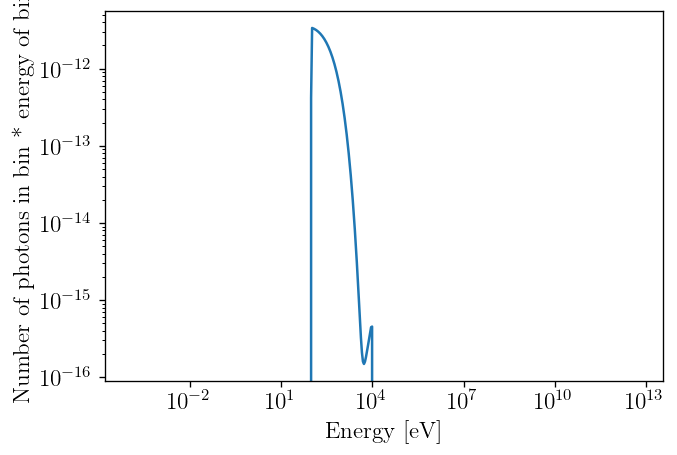

In [27]:
plt.plot(s.eng, s.N*s.eng)
plt.loglog()
#plt.ylim(1e-15,None)
plt.xlabel('Energy [eV]')
plt.ylabel('Number of photons in bin * energy of bin')

In [24]:
import matplotlib.pyplot as plt

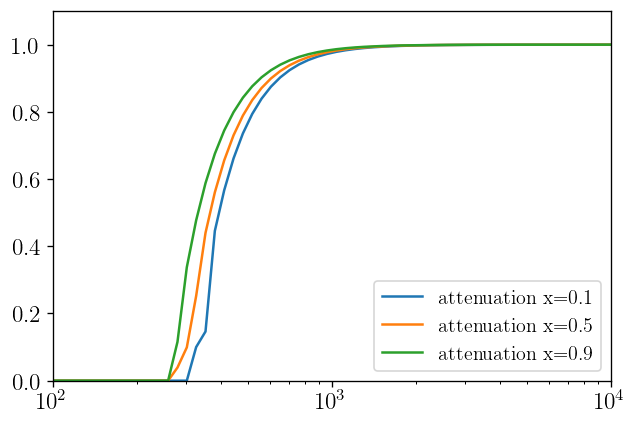

In [31]:
for x in [0.1, 0.5, 0.9]:
    attenuation_arr = np.array(tf_wrapper.attenuation_arr(rs=1+5, x=x))
    plt.plot(abscs['photE'], attenuation_arr, label=f'attenuation x={x}')
NE = s.eng * s.N
#plt.fill_between(s.eng, NE/NE[179], label='xray emission (unnormalized)', alpha=0.5)
plt.xscale('log')
plt.xlim(100, 1e4)
plt.ylim(0, 1.1)
plt.legend()

In [29]:
phys.conformal_dx_between_z(5, 5.05)

26.770809672383685

In [ ]:
attenuation_arr = np.array(tf_wrapper.attenuation_arr(rs=1+z_current, x=0.1))